In [1]:
import pystac_client
import planetary_computer
import stackstac
import rioxarray
import xarray as xr
print(f"pystac-client: {pystac_client.__version__}")
print(f"stackstac:      {stackstac.__version__}")
print(f"rioxarray:      {rioxarray.__version__}")
print("✅ All Week 8 packages ready!")

pystac-client: 0.9.0
stackstac:      0.5.1
rioxarray:      0.19.0
✅ All Week 8 packages ready!


In [2]:
import pystac_client
import planetary_computer
import stackstac
import rioxarray
import xarray as xr
print(f"pystac-client: {pystac_client.__version__}")
print(f"stackstac:      {stackstac.__version__}")
print(f"rioxarray:      {rioxarray.__version__}")
print("✅ All Week 8 packages ready!")

pystac-client: 0.9.0
stackstac:      0.5.1
rioxarray:      0.19.0
✅ All Week 8 packages ready!


In [3]:
import pystac_client
import planetary_computer as pc

# Connect to Microsoft Planetary Computer STAC
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=pc.sign_inplace,
)

# Matai'an catchment bbox (lon_min, lat_min, lon_max, lat_max)
# Covers upper Wanrong barrier lake site → downstream Guangfu township
mataian_bbox = [121.28, 23.56, 121.52, 23.76]

# ACT 1: Pre-event baseline — before Typhoon Wipha (Jul 21, 2025)
search_pre = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=mataian_bbox,
    datetime="2025-06-01/2025-07-15",
    query={"eo:cloud_cover": {"lt": 20}},
)

items_pre = search_pre.item_collection()
print(f"Pre-event (Jun–early Jul 2025): {len(items_pre)} clean scenes")
for item in items_pre[:5]:
    print(f"  {item.id} | clouds={item.properties['eo:cloud_cover']:.1f}%")

Pre-event (Jun–early Jul 2025): 1 clean scenes
  S2A_MSIL2A_20250615T023141_R046_T51QUG_20250615T070417 | clouds=8.5%


In [4]:
# ACT 2: Mid-event — lake is present, NOT yet breached (pre Sep 23)
search_mid = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=mataian_bbox,
    datetime="2025-08-01/2025-09-20",
    query={"eo:cloud_cover": {"lt": 40}},   # Aug/Sep is monsoon — relax clouds
)
items_mid = search_mid.item_collection()
print(f"Mid-event (Aug–mid Sep 2025): {len(items_mid)} usable scenes")

Mid-event (Aug–mid Sep 2025): 7 usable scenes


In [5]:
# ACT 3: Post-event — lake gone, Guangfu buried
search_post = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=mataian_bbox,
    datetime="2025-09-25/2025-11-15",
    query={"eo:cloud_cover": {"lt": 30}},
)
items_post = search_post.item_collection()
print(f"Post-event (late Sep–Nov 2025): {len(items_post)} usable scenes")

Post-event (late Sep–Nov 2025): 5 usable scenes


Baseline scene: S2A_MSIL2A_20250615T023141_R046_T51QUG_20250615T070417 (8.5% clouds)
TCI shape: (3, 687, 687), CRS: EPSG:32651


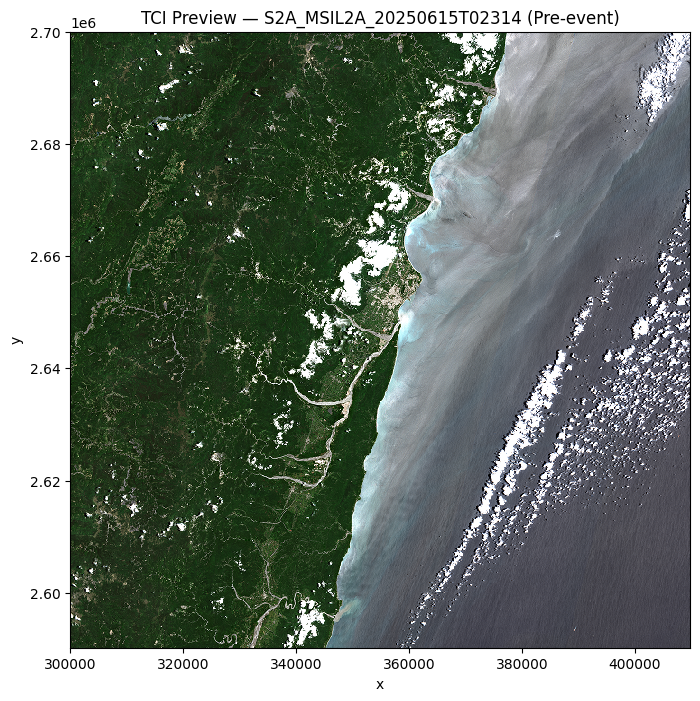

In [6]:
import rioxarray as rxr
import matplotlib.pyplot as plt

# Pick the least-cloudy Pre-event item as our baseline
best_pre = min(items_pre, key=lambda i: i.properties["eo:cloud_cover"])
print(f"Baseline scene: {best_pre.id} ({best_pre.properties['eo:cloud_cover']:.1f}% clouds)")

# Stream the TCI asset (True Color preview)
tci_href = best_pre.assets["visual"].href   # 'visual' == TCI on Planetary Computer
tci = rxr.open_rasterio(tci_href, overview_level=3)   # overview = low-res preview
print(f"TCI shape: {tci.shape}, CRS: {tci.rio.crs}")

# Plot
fig, ax = plt.subplots(figsize=(8, 8))
tci.plot.imshow(ax=ax)
ax.set_title(f"TCI Preview — {best_pre.id[:25]} (Pre-event)")
plt.show()

In [7]:
import stackstac

# Stream only the bands we need (not the whole 12-band cube)
wanted_bands = ["B02", "B03", "B04", "B08", "B11", "B12"]

cube = stackstac.stack(
    [best_pre],
    assets=wanted_bands,
    epsg=32651,             # UTM 51N — Taiwan east coast
    resolution=10,          # upsample 20m SWIR to 10m for uniform grid
    bounds_latlon=mataian_bbox,
    chunksize=2048,
)

print(f"Cube dims: {dict(cube.sizes)}")
print(f"Bands: {list(cube.band.values)}")
print("✅ STAC streaming works — ready for Week 8")

Cube dims: {'time': 1, 'band': 6, 'y': 2243, 'x': 2474}
Bands: [np.str_('B02'), np.str_('B03'), np.str_('B04'), np.str_('B08'), np.str_('B11'), np.str_('B12')]
✅ STAC streaming works — ready for Week 8


In [8]:
import geopandas as gpd
from shapely.geometry import Point
from pathlib import Path

# --- 1. Build the in-memory GeoDataFrame ---
rows = [
    {"name": "Guangfu_Station",        "cn_name": "光復火車站",        "node_type": "critical_infra", "priority": 2, "lon": 121.4235, "lat": 23.6719},
    {"name": "Guangfu_Elementary",     "cn_name": "光復國小",          "node_type": "shelter",        "priority": 1, "lon": 121.4240, "lat": 23.6688},
    {"name": "Guangfu_Township_Office","cn_name": "光復鄉公所",        "node_type": "shelter",        "priority": 1, "lon": 121.4210, "lat": 23.6684},
    {"name": "Mataian_Hwy9_Bridge",    "cn_name": "台9線馬太鞍溪橋",   "node_type": "bridge",         "priority": 1, "lon": 121.4100, "lat": 23.6380},
    {"name": "Foxu_Debris_Zone",       "cn_name": "佛祖街沉積區中心",  "node_type": "critical_infra", "priority": 3, "lon": 121.4260, "lat": 23.6640},
]

# TODO 1: Convert `rows` into a GeoDataFrame.
#   - geometry column should be built with Point(lon, lat)
#   - initial CRS is EPSG:4326 (WGS84 lon/lat)

gdf = gpd.GeoDataFrame(
    rows,
    geometry=[Point(r["lon"], r["lat"]) for r in rows],
    crs="EPSG:4326",
).drop(columns=["lon", "lat"])

# TODO 2: Reproject to EPSG:3826 (TWD97 / TM2 — Taiwan official)
gdf_3826 = gdf.to_crs("EPSG:3826")

# TODO 3: Ensure the output folder exists
out_path = Path("data/guangfu_overlay.gpkg")
out_path.parent.mkdir(parents=True, exist_ok=True)

# TODO 4: Save as GeoPackage, driver="GPKG", layer="guangfu"
gdf_3826.to_file(out_path, driver="GPKG", layer="guangfu")

print(f"✅ Saved {len(gdf_3826)} nodes → {out_path}")
print(gdf_3826[["name", "cn_name", "node_type", "priority"]])

✅ Saved 5 nodes → data\guangfu_overlay.gpkg
                      name   cn_name       node_type  priority
0          Guangfu_Station     光復火車站  critical_infra         2
1       Guangfu_Elementary      光復國小         shelter         1
2  Guangfu_Township_Office     光復鄉公所         shelter         1
3      Mataian_Hwy9_Bridge  台9線馬太鞍溪橋          bridge         1
4         Foxu_Debris_Zone  佛祖街沉積區中心  critical_infra         3


In [9]:
# Verify the file is readable and the schema is correct
check = gpd.read_file("data/guangfu_overlay.gpkg", layer="guangfu")
assert len(check) == 5,               f"Expected 5 rows, got {len(check)}"
assert check.crs.to_epsg() == 3826,   f"Expected EPSG:3826, got {check.crs}"
assert set(check["node_type"]) == {"shelter", "critical_infra", "bridge"}, \
       "node_type must include all three categories"
print("✅ guangfu_overlay.gpkg passes all schema checks")

✅ guangfu_overlay.gpkg passes all schema checks
